In [1]:
# =========================================================
# (FE) FEATURE ENGINEERING
# =========================================================

# =========================================================
# 1. IMPORTAR LIBRERÍAS
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    skew,
    chi2_contingency,
    f_oneway
)

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    LabelEncoder,
    PowerTransformer
)

from sklearn.feature_selection import VarianceThreshold

from sklearn.decomposition import (
    PCA,
    FactorAnalysis
)

import warnings
warnings.filterwarnings("ignore")

# Configuración visual
plt.style.use("default")
sns.set_theme(style="whitegrid")

In [2]:
# =========================================================
# 2. CARGAR DATASET
# =========================================================

ruta = r"vibracion.csv"

df = pd.read_csv(ruta)

In [3]:

# =========================================================
# 3. INSPECCIÓN INICIAL
# =========================================================

print("\nPrimeras filas:")
print(df.head())

print("\nInformación general:")
print(df.info())

print("\nDescripción estadística:")
print(df.describe())

print("\nValores nulos:")
print(df.isnull().sum())


Primeras filas:
             timesTamp parameterName   sensorId  RMSVelocityH  RMSVelocityV  \
0  2025-01-01 00:00:00        Pump_1  189310001         0.297         0.255   
1  2025-01-01 00:30:00        Pump_1  189310001         0.299         0.243   
2  2025-01-01 01:00:00        Pump_1  189310001         0.297         0.248   
3  2025-01-01 01:30:00        Pump_1  189310001         0.307         0.247   
4  2025-01-01 02:00:00        Pump_1  189310001         0.302         0.256   

   RMSVelocityA  
0         0.353  
1         0.359  
2         0.350  
3         0.344  
4         0.357  

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timesTamp      52560 non-null  object 
 1   parameterName  52560 non-null  object 
 2   sensorId       52560 non-null  int64  
 3   RMSVelocityH   52560 non-null  float64
 4   R

In [4]:
# =========================================================
# 4. LIMPIEZA BÁSICA
# =========================================================

# Eliminar duplicados
df = df.drop_duplicates()

# Rellenar valores nulos numéricos con media
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

print("\nDataset limpio correctamente.")

# Justificación: Los valores faltantes pueden afectar el rendimiento del modelo y generar sesgos.


Dataset limpio correctamente.


In [5]:
# =========================================================
# 5. GENERACIÓN DE NUEVAS CARACTERÍSTICAS
# =========================================================

numeric_cols = df.select_dtypes(include=np.number).columns

if len(numeric_cols) >= 3:

    df["vibracion_rms"] = np.sqrt(
        (
            df[numeric_cols[0]]**2 +
            df[numeric_cols[1]]**2 +
            df[numeric_cols[2]]**2
        ) / 3
    )

print("\nNueva característica creada:")
print(df.head())

# Justificación: Permite crear variables más representativas y capturar patrones complejos.


Nueva característica creada:
             timesTamp parameterName   sensorId  RMSVelocityH  RMSVelocityV  \
0  2025-01-01 00:00:00        Pump_1  189310001         0.297         0.255   
1  2025-01-01 00:30:00        Pump_1  189310001         0.299         0.243   
2  2025-01-01 01:00:00        Pump_1  189310001         0.297         0.248   
3  2025-01-01 01:30:00        Pump_1  189310001         0.307         0.247   
4  2025-01-01 02:00:00        Pump_1  189310001         0.302         0.256   

   RMSVelocityA  vibracion_rms  
0         0.353   1.092982e+08  
1         0.359   1.092982e+08  
2         0.350   1.092982e+08  
3         0.344   1.092982e+08  
4         0.357   1.092982e+08  


In [6]:
# =========================================================
# 6. DISCRETIZACIÓN (BINNING)
# =========================================================

# Convertir variable continua en categorías
if "vibracion_rms" in df.columns:

    df["nivel_vibracion"] = pd.cut(
        df["vibracion_rms"],
        bins=3,
        labels=["Baja", "Media", "Alta"]
    )

print("\nVariable discretizada:")
print(df["nivel_vibracion"].value_counts())

# Justificación: Convierte variables continuas en categorías, facilitando interpretación y análisis.


Variable discretizada:
nivel_vibracion
Baja     17520
Media    17520
Alta     17520
Name: count, dtype: int64


In [7]:
# =========================================================
# 7. CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# =========================================================

# =========================================================
# 7.1 LABEL ENCODING
# =========================================================

le = LabelEncoder()

if "nivel_vibracion" in df.columns:

    df["nivel_vibracion_cod"] = le.fit_transform(
        df["nivel_vibracion"]
    )

# Justificación: Machine Learning requiere variables numéricas.

In [8]:
# =========================================================
# 7.2 ONE HOT ENCODING
# =========================================================

categorical_cols = df.select_dtypes(include="object").columns

if len(categorical_cols) > 0:

    df = pd.get_dummies(
        df,
        columns=categorical_cols,
        drop_first=True
    )

print("\nDataset después de codificación:")
print(df.head())

# Justificación: Esta codificación evita relaciones incorrectas entre categorías.


Dataset después de codificación:
    sensorId  RMSVelocityH  RMSVelocityV  RMSVelocityA  vibracion_rms  \
0  189310001         0.297         0.255         0.353   1.092982e+08   
1  189310001         0.299         0.243         0.359   1.092982e+08   
2  189310001         0.297         0.248         0.350   1.092982e+08   
3  189310001         0.307         0.247         0.344   1.092982e+08   
4  189310001         0.302         0.256         0.357   1.092982e+08   

  nivel_vibracion  nivel_vibracion_cod  timesTamp_2025-01-01 00:30:00  \
0            Baja                    1                          False   
1            Baja                    1                           True   
2            Baja                    1                          False   
3            Baja                    1                          False   
4            Baja                    1                          False   

   timesTamp_2025-01-01 01:00:00  timesTamp_2025-01-01 01:30:00  ...  \
0               

In [9]:
# =========================================================
# 8. ESCALAMIENTO
# =========================================================

numeric_df = df.select_dtypes(include=np.number)

# =========================================================
# 8.1 ESTANDARIZACIÓN
# =========================================================

scaler_std = StandardScaler()

X_std = scaler_std.fit_transform(numeric_df)

X_std = pd.DataFrame(
    X_std,
    columns=numeric_df.columns
)

print("\nDatos estandarizados:")
print(X_std.head())

# Justificación: Se igualó la escala de las variables para evitar sesgos en el modelo.



Datos estandarizados:
   sensorId  RMSVelocityH  RMSVelocityV  RMSVelocityA  vibracion_rms  \
0 -1.224745     -1.848900     -1.539319     -1.613019      -1.224745   
1 -1.224745     -1.844814     -1.554934     -1.603644      -1.224745   
2 -1.224745     -1.848900     -1.548428     -1.617706      -1.224745   
3 -1.224745     -1.828467     -1.549729     -1.627081      -1.224745   
4 -1.224745     -1.838684     -1.538017     -1.606769      -1.224745   

   nivel_vibracion_cod  
0                  0.0  
1                  0.0  
2                  0.0  
3                  0.0  
4                  0.0  


In [10]:
# =========================================================
# 8.2 NORMALIZACIÓN MIN-MAX
# =========================================================

scaler_mm = MinMaxScaler()

X_mm = scaler_mm.fit_transform(numeric_df)

X_mm = pd.DataFrame(
    X_mm,
    columns=numeric_df.columns
)

print("\nDatos normalizados:")
print(X_mm.head())

# Justificación: Los datos se ajustaron entre 0 y 1 para facilitar el entrenamiento.


Datos normalizados:
   sensorId  RMSVelocityH  RMSVelocityV  RMSVelocityA  vibracion_rms  \
0       0.0      0.063241      0.055199      0.083563            0.0   
1       0.0      0.064032      0.051854      0.085626            0.0   
2       0.0      0.063241      0.053248      0.082531            0.0   
3       0.0      0.067194      0.052969      0.080468            0.0   
4       0.0      0.065217      0.055478      0.084938            0.0   

   nivel_vibracion_cod  
0                  0.5  
1                  0.5  
2                  0.5  
3                  0.5  
4                  0.5  


In [11]:
# =========================================================
# 9. TRANSFORMACIONES
# =========================================================

# =========================================================
# 9.1 TRANSFORMACIÓN LOGARÍTMICA
# =========================================================

if "vibracion_rms" in df.columns:

    df["vibracion_log"] = np.log1p(df["vibracion_rms"])

# Justificación: Se redujo el impacto de valores extremos.

In [12]:
# =========================================================
# 9.2 TRANSFORMACIÓN YEO-JOHNSON
# =========================================================

pt = PowerTransformer(method="yeo-johnson")

X_power = pt.fit_transform(numeric_df)

X_power = pd.DataFrame(
    X_power,
    columns=numeric_df.columns
)

print("\nDatos transformados (Yeo-Johnson):")
print(X_power.head())

# Justificación: Se buscó mejorar la distribución de los datos.


Datos transformados (Yeo-Johnson):
   sensorId  RMSVelocityH  RMSVelocityV  RMSVelocityA  vibracion_rms  \
0 -1.224745     -1.819457     -1.705384     -1.684874      -1.224745   
1 -1.224745     -1.815586     -1.727621     -1.673940      -1.224745   
2 -1.224745     -1.819457     -1.718342     -1.690346      -1.224745   
3 -1.224745     -1.800096     -1.720196     -1.701301      -1.224745   
4 -1.224745     -1.809779     -1.703536     -1.677583      -1.224745   

   nivel_vibracion_cod  
0             0.090648  
1             0.090648  
2             0.090648  
3             0.090648  
4             0.090648  


In [13]:
# =========================================================
# 10. ANÁLISIS DE ASIMETRÍA
# =========================================================

print("\nAsimetría de variables:")

for col in numeric_df.columns:

    print(f"{col}: {skew(numeric_df[col]):.4f}")

# Justificación: Se verificó qué variables tienen distribuciones poco equilibradas.


Asimetría de variables:
sensorId: 0.0000
RMSVelocityH: -0.1228
RMSVelocityV: 0.1733
RMSVelocityA: 0.0536
vibracion_rms: 0.0000
nivel_vibracion_cod: 0.0000


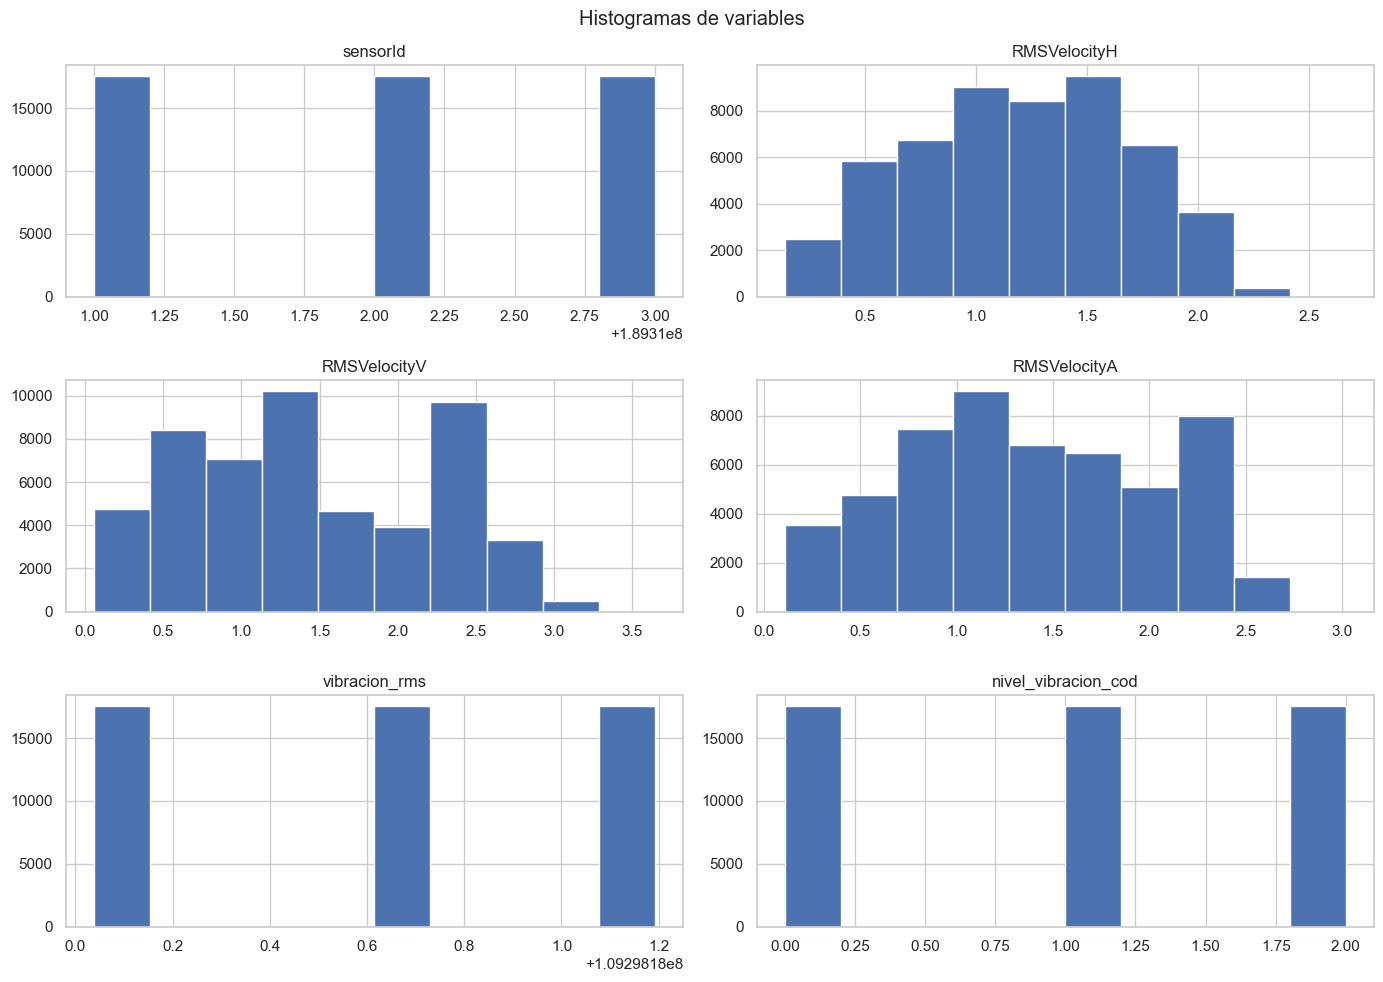

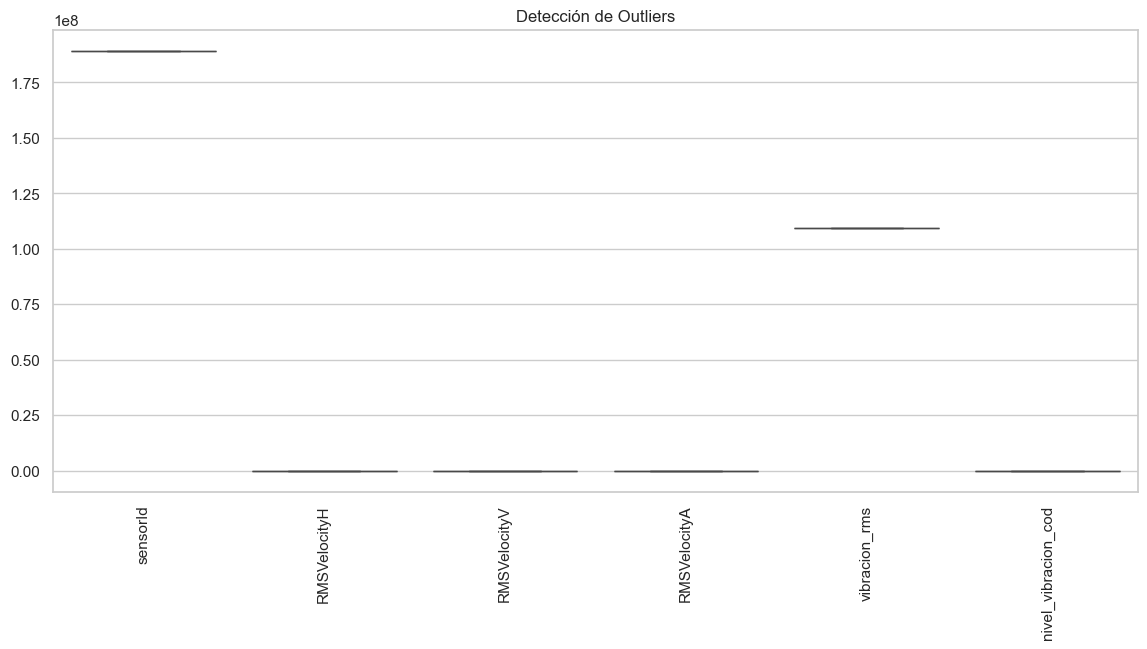

In [14]:
# =========================================================
# 11. VISUALIZACIONES
# =========================================================

# Histogramas
numeric_df.hist(figsize=(14,10))
plt.suptitle("Histogramas de variables")
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(14,6))
sns.boxplot(data=numeric_df)
plt.xticks(rotation=90)
plt.title("Detección de Outliers")
plt.show()

# Justificación: Las gráficas ayudan a entender mejor el comportamiento de los datos.


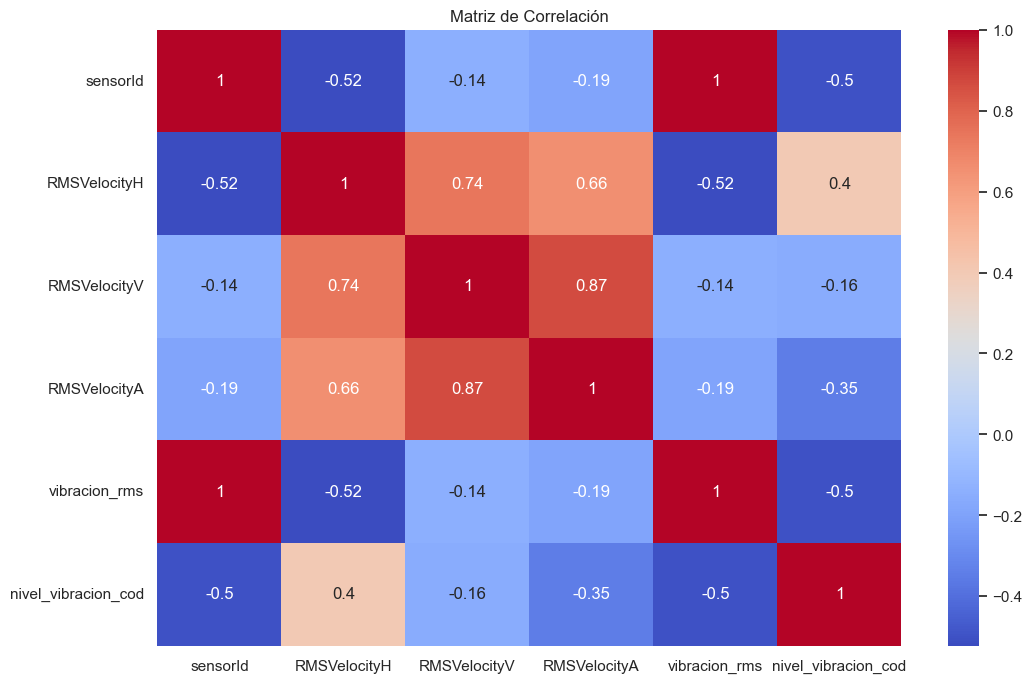

In [15]:
# =========================================================
# 12. MATRIZ DE CORRELACIÓN
# =========================================================

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True
)

plt.title("Matriz de Correlación")
plt.show()

# Justificación: Se identificaron relaciones fuertes entre variables.

In [16]:
# =========================================================
# 13. SELECCIÓN DE CARACTERÍSTICAS
# =========================================================

selector = VarianceThreshold(threshold=0.01)

X_var = selector.fit_transform(numeric_df)

selected_features = numeric_df.columns[
    selector.get_support()
]

print("\nCaracterísticas seleccionadas:")
print(selected_features)

# Justificación: e eliminaron variables con muy poca información.


Características seleccionadas:
Index(['sensorId', 'RMSVelocityH', 'RMSVelocityV', 'RMSVelocityA',
       'vibracion_rms', 'nivel_vibracion_cod'],
      dtype='object')


In [17]:
# =========================================================
# 14. CHI-CUADRADO
# =========================================================

if "nivel_vibracion" in df.columns:

    tabla = pd.crosstab(
        df["nivel_vibracion"],
        df["nivel_vibracion_cod"]
    )

    chi2, p, dof, expected = chi2_contingency(tabla)

    print("\nChi-cuadrado")
    print("Chi2:", chi2)
    print("p-value:", p)


# Justificación: Se evaluó si existe relación entre variables categóricas.


Chi-cuadrado
Chi2: 105120.0
p-value: 0.0


In [18]:
# =========================================================
# 15. ANOVA
# =========================================================

if "nivel_vibracion" in df.columns:

    grupos = []

    for categoria in df["nivel_vibracion"].unique():

        grupo = df[
            df["nivel_vibracion"] == categoria
        ]["vibracion_rms"]

        grupos.append(grupo)

    f_stat, p_value = f_oneway(*grupos)

    print("\nANOVA")
    print("F-statistic:", f_stat)
    print("p-value:", p_value)


# Justificación: Se compararon diferencias entre grupos.


ANOVA
F-statistic: 8.436906649440782e+19
p-value: 0.0



PCA
Número de componentes: 3

Varianza explicada:
[0.51734702 0.3446633  0.11274011]


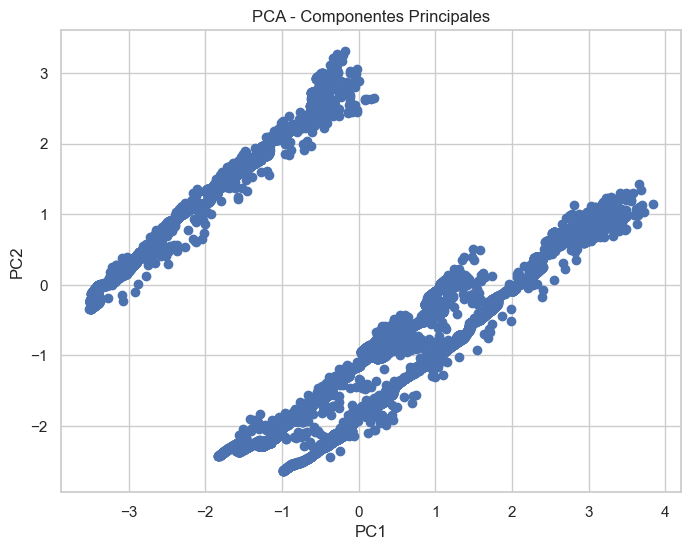

In [19]:

# =========================================================
# 16. PCA
# =========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(numeric_df)

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("\nPCA")
print("Número de componentes:", pca.n_components_)

print("\nVarianza explicada:")
print(pca.explained_variance_ratio_)

# Visualización PCA
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.title("PCA - Componentes Principales")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Justificación: PCA redujo variables manteniendo la mayor información posible.


Factor Analysis
[[-1.22474488 -1.83694502]
 [-1.22474488 -1.84861075]
 [-1.22474488 -1.84513056]
 [-1.22474488 -1.84578648]
 [-1.22474488 -1.83434475]]


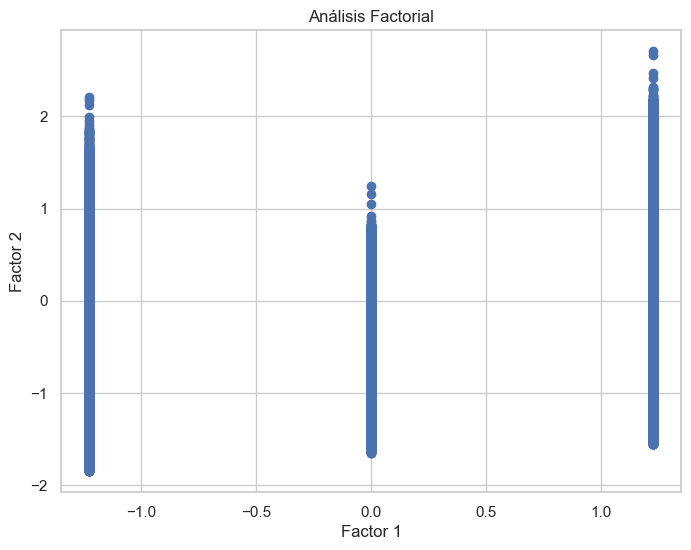

In [20]:
# =========================================================
# 17. ANÁLISIS FACTORIAL (FA)
# =========================================================

fa = FactorAnalysis(n_components=2)

X_fa = fa.fit_transform(X_scaled)

print("\nFactor Analysis")
print(X_fa[:5])

# Visualización FA
plt.figure(figsize=(8,6))

plt.scatter(
    X_fa[:,0],
    X_fa[:,1]
)

plt.title("Análisis Factorial")
plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.show()

# Justificación: Se buscaron factores ocultos dentro de las variables.


In [21]:
# =========================================================
# 18. EXPORTAR DATASET PROCESADO
# =========================================================

df.to_csv(
    "dataset_procesado_completo.csv",
    index=False
)

print("Dataset exportado correctamente")

# Justificación: Se guardó el dataset final para usarlo posteriormente.

Dataset exportado correctamente


In [22]:
# =========================================================
# CONCLUSIONES - PREPARACIÓN DE LOS DATOS (CRISP-ML)
# =========================================================

"""
Durante la fase de preparación de los datos se aplicaron
distintas técnicas de limpieza, transformación y reducción
de características para obtener un dataset más adecuado
para modelos de Machine Learning.

Primero, se eliminaron registros duplicados y se trataron
valores faltantes para mejorar la calidad de los datos.
Posteriormente, se generaron nuevas variables como RMS,
permitiendo representar mejor el comportamiento de las
señales de vibración.

También se aplicaron procesos de discretización,
codificación, normalización y estandarización para adaptar
los datos a formatos compatibles con algoritmos de
aprendizaje automático.

Además, se utilizaron técnicas de selección y extracción
de características como correlación, umbral de varianza,
ANOVA, Chi-cuadrado, PCA y análisis factorial, logrando
reducir redundancia y dimensionalidad en el dataset.

Finalmente, esta etapa permitió obtener datos más limpios,
organizados y útiles para las siguientes fases de modelado
y evaluación dentro de la metodología CRISP-ML.
"""

'\nDurante la fase de preparación de los datos se aplicaron\ndistintas técnicas de limpieza, transformación y reducción\nde características para obtener un dataset más adecuado\npara modelos de Machine Learning.\n\nPrimero, se eliminaron registros duplicados y se trataron\nvalores faltantes para mejorar la calidad de los datos.\nPosteriormente, se generaron nuevas variables como RMS,\npermitiendo representar mejor el comportamiento de las\nseñales de vibración.\n\nTambién se aplicaron procesos de discretización,\ncodificación, normalización y estandarización para adaptar\nlos datos a formatos compatibles con algoritmos de\naprendizaje automático.\n\nAdemás, se utilizaron técnicas de selección y extracción\nde características como correlación, umbral de varianza,\nANOVA, Chi-cuadrado, PCA y análisis factorial, logrando\nreducir redundancia y dimensionalidad en el dataset.\n\nFinalmente, esta etapa permitió obtener datos más limpios,\norganizados y útiles para las siguientes fases de mod